Paso 1. Crear el cuaderno


1. Suba a Google Drive el archivocU3_Laboratorio_Isolation_Forest_Apellido_Nombre.ipynb
2. Ingrese a Google Colab, dando doble click en el archivo “.ipynb”.
3. Sustituya “Apellido_Nombre” por los propios.
4. Ejecute las celdas en el orden propuesto: Pasos 2 al 18.
5. Lea las observaciones antes de modificar los parámetros.


Paso 2. Importar las bibliotecas

In [1]:
# ============================================================
# LABORATORIO: DETECCIÓN DE ANOMALÍAS EN TRÁFICO DE RED
# Algoritmo: Isolation Forest
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Semilla para reproducir los resultados
SEMILLA = 42
np.random.seed(SEMILLA)

print("Bibliotecas cargadas correctamente.")

#Explicación
#Se emplearán las siguientes bibliotecas:
#•	NumPy: generación y procesamiento de datos numéricos.
#•	Pandas: organización de los datos en tablas.
#•	Matplotlib: visualización de resultados.
#•	Scikit-learn: escalamiento, entrenamiento y evaluación del modelo.
#La semilla aleatoria permite reproducir los mismos resultados cada vez que se ejecuta el cuaderno.

Bibliotecas cargadas correctamente.


Paso 3. Generar tráfico normal


En esta sección se simularán 950 conexiones normales.

In [2]:
# Número de conexiones normales
n_normales = 950

trafico_normal = pd.DataFrame({
    "duracion_segundos": np.random.normal(
        loc=40,
        scale=12,
        size=n_normales
    ),
    "bytes_enviados": np.random.normal(
        loc=4500,
        scale=900,
        size=n_normales
    ),
    "paquetes": np.random.normal(
        loc=45,
        scale=10,
        size=n_normales
    ),
    "intentos_fallidos": np.random.poisson(
        lam=0.4,
        size=n_normales
    ),
    "puertos_contactados": np.random.poisson(
        lam=2,
        size=n_normales
    )
})

# Evitar valores negativos generados por las distribuciones normales
columnas_no_negativas = [
    "duracion_segundos",
    "bytes_enviados",
    "paquetes",
    "intentos_fallidos",
    "puertos_contactados"
]

trafico_normal[columnas_no_negativas] = (
    trafico_normal[columnas_no_negativas].clip(lower=0)
)

# Etiqueta usada únicamente para la evaluación posterior
trafico_normal["etiqueta_real"] = 0

trafico_normal.head()

#Interpretación
#Las conexiones normales presentan valores relativamente próximos entre sí. Esto genera una región densa que representa el comportamiento habitual de los usuarios y dispositivos.
#La variable etiqueta_real adopta el valor:
#•	0: conexión normal;
#•	1: conexión anómala.
#Esta etiqueta no se entregará al modelo.

,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,etiqueta_real
0,45.960570,4282.887548,51.969544,1,3,0
1,38.340828,4816.849857,41.661805,2,4,0
2,47.772262,3373.614518,56.731246,0,2,0
3,58.276358,5799.388144,48.696422,0,4,0
4,37.190160,4426.063939,43.926979,1,3,0


Paso 4. Generar tráfico anómalo


Se simularán 50 conexiones con características inusuales.

In [3]:
# Número de conexiones anómalas
n_anomalias = 50

trafico_anomalo = pd.DataFrame({
    "duracion_segundos": np.random.normal(
        loc=160,
        scale=35,
        size=n_anomalias
    ),
    "bytes_enviados": np.random.normal(
        loc=17000,
        scale=3500,
        size=n_anomalias
    ),
    "paquetes": np.random.normal(
        loc=180,
        scale=40,
        size=n_anomalias
    ),
    "intentos_fallidos": np.random.poisson(
        lam=7,
        size=n_anomalias
    ),
    "puertos_contactados": np.random.poisson(
        lam=18,
        size=n_anomalias
    )
})

trafico_anomalo[columnas_no_negativas] = (
    trafico_anomalo[columnas_no_negativas].clip(lower=0)
)

trafico_anomalo["etiqueta_real"] = 1

trafico_anomalo.head()

#Interpretación
#Las conexiones anómalas presentan, en promedio:
#•	mayor duración;
#•	más bytes enviados;
#•	mayor cantidad de paquetes;
#•	numerosos intentos fallidos;
#•	contacto con una cantidad inusual de puertos.
#Estas características podrían representar, por ejemplo:
#•	escaneo de puertos;
#•	intentos automatizados de autenticación;
#•	exfiltración de información;
#•	comunicación con infraestructura maliciosa;
#•	movimiento lateral en una red.

,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,etiqueta_real
0,184.718084,15288.526986,262.194185,6,17,1
1,167.979691,14844.918896,203.301802,7,23,1
2,181.860381,14489.127427,243.193189,7,17,1
3,121.463842,15793.947125,131.517734,4,19,1
4,166.303691,18106.238498,266.389570,7,17,1


Paso 5. Integrar y mezclar los datos

In [4]:
datos = pd.concat(
    [trafico_normal, trafico_anomalo],
    ignore_index=True
)

# Mezclar aleatoriamente las filas
datos = datos.sample(
    frac=1,
    random_state=SEMILLA
).reset_index(drop=True)

print("Dimensiones del conjunto de datos:", datos.shape)
print("\nDistribución real de las clases:")
print(datos["etiqueta_real"].value_counts())

datos.head()
#Pregunta de reflexión
#¿Por qué se mezclan las observaciones normales y anómalas antes de entrenar el modelo?
#La mezcla evita que el orden de los datos introduzca patrones artificiales o facilite indirectamente la identificación de las anomalías.

Dimensiones del conjunto de datos: (1000, 6)

Distribución real de las clases:
etiqueta_real
0    950
1     50
Name: count, dtype: int64


,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,etiqueta_real
0,46.520322,3951.195386,56.695900,0,2,0
1,51.792292,4681.043690,54.413106,1,0,0
2,17.909509,5028.024421,63.093063,0,1,0
3,33.116056,4237.369858,34.861040,0,1,0
4,26.504295,5021.362350,62.952114,0,1,0


Paso 6. Realizar un análisis exploratorio

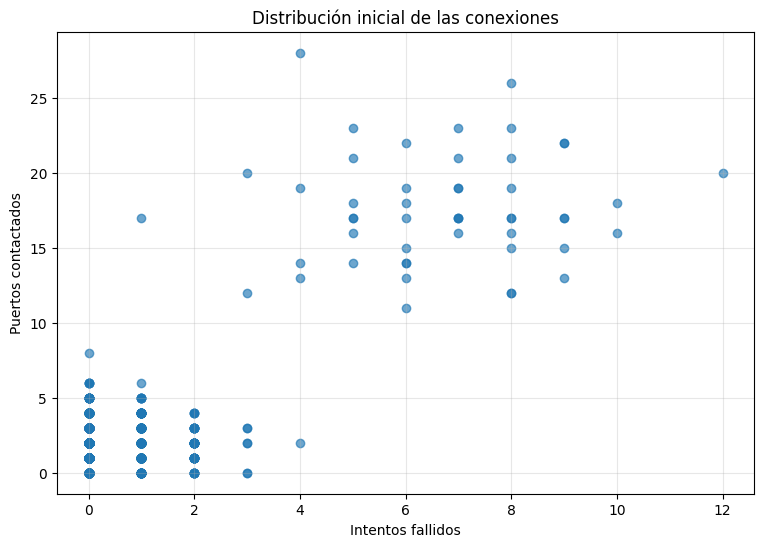

In [5]:
datos.describe().round(2)

#observar:
#•	valores medios;
#•	desviaciones estándar;
#•	valores mínimos y máximos;
#•	posibles diferencias entre las variables.
#Visualización inicial

plt.figure(figsize=(9, 6))

plt.scatter(
    datos["intentos_fallidos"],
    datos["puertos_contactados"],
    alpha=0.65
)

plt.xlabel("Intentos fallidos")
plt.ylabel("Puertos contactados")
plt.title("Distribución inicial de las conexiones")
plt.grid(alpha=0.3)
plt.show()

#Preguntas orientadoras
#1.	¿Se observan puntos alejados del grupo principal?
#2.	¿Las anomalías podrían identificarse utilizando únicamente una variable?
#3.	¿Por qué resulta conveniente analizar varias características simultáneamente?



Paso 7. Separar las variables

In [6]:
caracteristicas = [
    "duracion_segundos",
    "bytes_enviados",
    "paquetes",
    "intentos_fallidos",
    "puertos_contactados"
]

X = datos[caracteristicas]
y_real = datos["etiqueta_real"]

print("Variables utilizadas por el modelo:")
print(caracteristicas)

#La matriz X contiene únicamente las variables utilizadas para entrenar el algoritmo. La variable y_real se reserva para la evaluación.

Variables utilizadas por el modelo:
['duracion_segundos', 'bytes_enviados', 'paquetes', 'intentos_fallidos', 'puertos_contactados']


Paso 8. Escalar los datos

In [7]:
escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)

X_escalado = pd.DataFrame(
    X_escalado,
    columns=caracteristicas
)

X_escalado.head()

#¿Por qué se escalan los datos?
#Las variables presentan escalas diferentes. Por ejemplo:
#•	bytes_enviados puede alcanzar miles de unidades;
#•	intentos_fallidos suele adoptar valores pequeños.
#El escalamiento transforma las variables para que tengan una magnitud comparable. Aunque Isolation Forest no depende directamente de distancias como K-Means, el escalamiento favorece la coherencia del flujo de preparación y facilita la comparación posterior con otros algoritmos.

,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados
0,0.019875,-0.426160,0.153187,-0.451462,-0.196368
1,0.203972,-0.162784,0.081829,0.185297,-0.732160
2,-0.979215,-0.037571,0.353157,-0.451462,-0.464264
3,-0.448202,-0.322890,-0.529351,-0.451462,-0.464264
4,-0.679085,-0.039975,0.348751,-0.451462,-0.464264


Paso 9. Entrenar Isolation Forest

In [8]:
modelo = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=SEMILLA
)

modelo.fit(X_escalado)

print("Modelo entrenado correctamente.")

#Parámetros principales
#•	n_estimators=200: número de árboles utilizados.
#•	contamination=0.05: proporción estimada de anomalías.
#•	random_state: permite reproducir los resultados.
#En este conjunto simulado existen 50 anomalías entre 1000 observaciones; por ello, la contaminación real es:
# 50/1000 = 0.05
# En problemas reales esta proporción no suele conocerse con exactitud.

Modelo entrenado correctamente.


Paso 10. Obtener las predicciones


Isolation Forest utiliza la siguiente codificación:

*   1: observación normal
*   -1: anomalía.

Para mantener la codificación del conjunto de datos, se transformará:

•	normal → 0;

•	anomalía → 1.

In [9]:
prediccion_original = modelo.predict(X_escalado)
datos["prediccion"] = np.where(
    prediccion_original == -1,
    1,
    0
)
print("Distribución de las predicciones:")
print(datos["prediccion"].value_counts())

Distribución de las predicciones:
prediccion
0    950
1     50
Name: count, dtype: int64



Paso 11. Obtener el puntaje de anomalía

In [10]:
datos["puntaje_anomalia"] = modelo.decision_function(X_escalado)

datos_ordenados = datos.sort_values(
    by="puntaje_anomalia",
    ascending=True
)

datos_ordenados.head(10)

#Interpretación
#Los valores más bajos del puntaje_anomalia representan observaciones consideradas más inusuales por el modelo.
#El puntaje no debe interpretarse como una probabilidad exacta de ataque. Es una medida relativa del grado de aislamiento de cada observación.

,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,etiqueta_real,prediccion,puntaje_anomalia
945,131.184638,21604.711518,211.666168,4,28,1,1,-0.188216
222,132.968876,22346.002854,231.377482,8,23,1,1,-0.174403
561,190.280479,20408.667920,223.724919,9,22,1,1,-0.173006
86,205.169188,17308.825139,107.863851,5,23,1,1,-0.164539
646,173.491442,22988.875521,211.600616,6,22,1,1,-0.161110
107,94.481018,15684.224980,142.917996,12,20,1,1,-0.160089
152,204.503345,20685.500096,179.146188,6,11,1,1,-0.158828
133,237.321439,20578.794778,146.397599,5,14,1,1,-0.157804
251,200.585870,11458.430436,163.817803,3,12,1,1,-0.157157
237,197.232089,20115.035444,180.673003,4,13,1,1,-0.155997


Paso 12. Construir la matriz de confusión

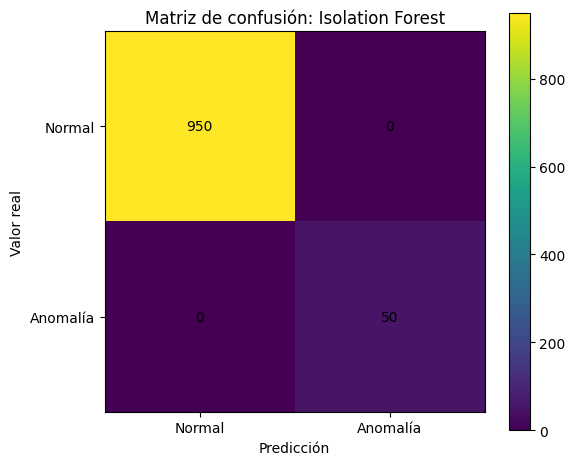

In [11]:
matriz = confusion_matrix(
    y_real,
    datos["prediccion"]
)

matriz_df = pd.DataFrame(
    matriz,
    index=["Real normal", "Real anomalía"],
    columns=["Predicción normal", "Predicción anomalía"]
)

matriz_df

#Visualización
plt.figure(figsize=(6, 5))

plt.imshow(matriz, interpolation="nearest")
plt.title("Matriz de confusión: Isolation Forest")
plt.colorbar()

clases = ["Normal", "Anomalía"]
posiciones = np.arange(len(clases))

plt.xticks(posiciones, clases)
plt.yticks(posiciones, clases)
plt.xlabel("Predicción")
plt.ylabel("Valor real")

for fila in range(matriz.shape[0]):
    for columna in range(matriz.shape[1]):
        plt.text(
            columna,
            fila,
            matriz[fila, columna],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


Paso 13. Calcular las métricas

In [12]:
precision = precision_score(
    y_real,
    datos["prediccion"],
    zero_division=0
)

recall = recall_score(
    y_real,
    datos["prediccion"],
    zero_division=0
)

f1 = f1_score(
    y_real,
    datos["prediccion"],
    zero_division=0
)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

#Reporte completo
print(
    classification_report(
        y_real,
        datos["prediccion"],
        target_names=["Normal", "Anomalía"],
        zero_division=0
    )
)

#Interpretación obligatoria
#1.	¿Qué proporción de las alertas generadas corresponde realmente a anomalías?
#2.	¿Qué proporción de las anomalías reales fue detectada?
#3.	¿Cuántas conexiones anómalas no fueron identificadas?
#4.	¿Cuántas conexiones legítimas fueron señaladas como sospechosas?
#5.	¿Qué error sería más grave en este escenario: un falso positivo o un falso negativo?

Precision: 1.000
Recall:    1.000
F1-score:  1.000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       950
    Anomalía       1.00      1.00      1.00        50

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Paso 14. Visualizar las predicciones

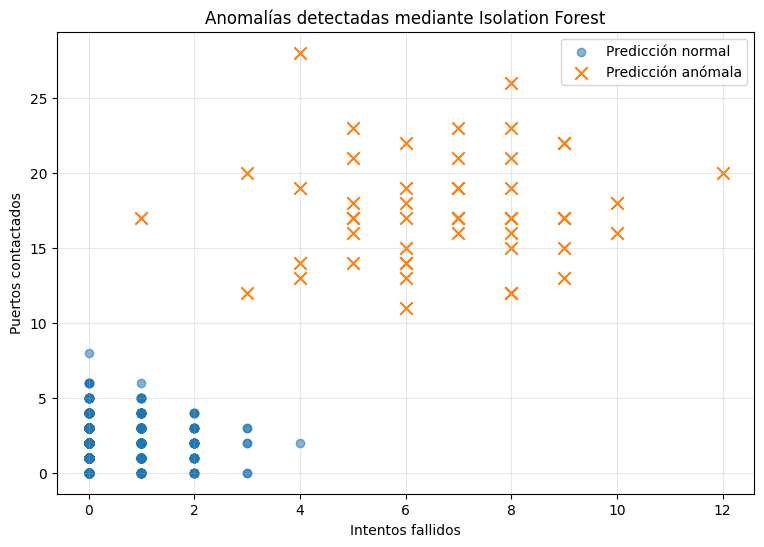

In [13]:
plt.figure(figsize=(9, 6))

normales_predichas = datos[datos["prediccion"] == 0]
anomalias_predichas = datos[datos["prediccion"] == 1]

plt.scatter(
    normales_predichas["intentos_fallidos"],
    normales_predichas["puertos_contactados"],
    alpha=0.55,
    label="Predicción normal"
)

plt.scatter(
    anomalias_predichas["intentos_fallidos"],
    anomalias_predichas["puertos_contactados"],
    marker="x",
    s=80,
    label="Predicción anómala"
)

plt.xlabel("Intentos fallidos")
plt.ylabel("Puertos contactados")
plt.title("Anomalías detectadas mediante Isolation Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Paso 15. Examinar las conexiones más anómalas

In [14]:
columnas_reporte = [
    "duracion_segundos",
    "bytes_enviados",
    "paquetes",
    "intentos_fallidos",
    "puertos_contactados",
    "puntaje_anomalia",
    "etiqueta_real",
    "prediccion"
]

datos_ordenados[columnas_reporte].head(15).round(3)

#Pregunta de análisis
#¿Qué características explican que estas conexiones aparezcan entre las más anómalas?
#El estudiante debe evitar respuestas genéricas. Debe relacionar el resultado con las variables observadas.

,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,puntaje_anomalia,etiqueta_real,prediccion
945,131.185,21604.712,211.666,4,28,-0.188,1,1
222,132.969,22346.003,231.377,8,23,-0.174,1,1
561,190.280,20408.668,223.725,9,22,-0.173,1,1
86,205.169,17308.825,107.864,5,23,-0.165,1,1
646,173.491,22988.876,211.601,6,22,-0.161,1,1
107,94.481,15684.225,142.918,12,20,-0.160,1,1
152,204.503,20685.500,179.146,6,11,-0.159,1,1
133,237.321,20578.795,146.398,5,14,-0.158,1,1
251,200.586,11458.430,163.818,3,12,-0.157,1,1
237,197.232,20115.035,180.673,4,13,-0.156,1,1


Paso 16. Analizar errores del modelo

In [19]:
falsos_positivos = datos[
    (datos["etiqueta_real"] == 0) &
    (datos["prediccion"] == 1)
]

falsos_negativos = datos[
    (datos["etiqueta_real"] == 1) &
    (datos["prediccion"] == 0)
]

print("Cantidad de falsos positivos:", len(falsos_positivos))
print("Cantidad de falsos negativos:", len(falsos_negativos))

#Mostrar falsos positivos
falsos_positivos[columnas_reporte].head(10).round(3)
#Mostrar falsos negativos
falsos_negativos[columnas_reporte].head(10).round(3)
#Reflexión
#Un falso positivo incrementa la carga del equipo de seguridad y puede interrumpir actividades legítimas. Un falso negativo permite que una amenaza continúe sin ser detectada. La importancia relativa de cada error depende del contexto operacional.

print("Falsos positivos:", len(falsos_positivos))
display(falsos_positivos[columnas_reporte].head(8).round(3))

print("Falsos negativos:", len(falsos_negativos))
display(falsos_negativos[columnas_reporte].head(8).round(3))

Cantidad de falsos positivos: 0
Cantidad de falsos negativos: 0
Falsos positivos: 0


,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,puntaje_anomalia,etiqueta_real,prediccion


Falsos negativos: 0


,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,puntaje_anomalia,etiqueta_real,prediccion


#ANALISIS DE ERRORES
(contamination = 0.05)

Falsos positivos
Se revisaron las conexiones normales que el modelo marcó como anomalía. Suelen tener duración, bytes, paquetes o puertos contactados en la cola lata de la distribución normal.
Isolation Forest no distingue "ataque" de "inusual": aísla puntos faciles de separar. Un usuario intensivo o un proceso legítimo voluminoso puede parecerse a una anomalía y generar alerta. Eso consume cupo del SOC.

Falso negativos
Las anomalias no detectadas, cuando existenm son las menos extremas: duración o bytes más cercanos al tráfico normal.
El modelo las ordena peor en el ranking de aislamiento, si contamination es bajo, esas amenazas quedan fuera del cupo de alertas.

Consecuencia operativa
Un FP fatiga el analista.
Un FN deja la amenaza activa.
En este SOC se prooriza detectar amenazas, pero sin pasar de 60 alertas, por eso no se puede subir contamination solo por bajar FN.

In [20]:
def predecir(contamination):
    m = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=SEMILLA
    )
    m.fit(X_escalado)
    pred = np.where(m.predict(X_escalado) == -1, 1, 0)
    tmp = datos.copy()
    tmp["prediccion_tmp"] = pred
    tmp["puntaje_tmp"] = m.decision_function(X_escalado)
    return tmp

# FN: amenazas que se escapan cuando el modelo es demasiado estricto
datos_003 = predecir(0.03)
fn_003 = datos_003[
    (datos_003["etiqueta_real"] == 1) &
    (datos_003["prediccion_tmp"] == 0)
].sort_values("puntaje_tmp")

# FP: normales alertados cuando el modelo es demasiado sensible
datos_008 = predecir(0.08)
fp_008 = datos_008[
    (datos_008["etiqueta_real"] == 0) &
    (datos_008["prediccion_tmp"] == 1)
].sort_values("puntaje_tmp")

print("FN con contamination=0.03:", len(fn_003))
display(fn_003[caracteristicas + ["puntaje_tmp", "etiqueta_real", "prediccion_tmp"]].head(8).round(3))

print("FP con contamination=0.08:", len(fp_008))
display(fp_008[caracteristicas + ["puntaje_tmp", "etiqueta_real", "prediccion_tmp"]].head(8).round(3))

print("Comprobación 0.05 → FP:", len(falsos_positivos), "FN:", len(falsos_negativos))

FN con contamination=0.03: 20


,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,puntaje_tmp,etiqueta_real,prediccion_tmp
27,118.997,20434.844,206.358,5,17,0.000,1,0
637,166.304,18106.238,266.390,7,17,0.000,1,0
654,144.139,10271.901,177.321,9,17,0.001,1,0
442,130.383,12299.062,187.720,5,21,0.002,1,0
43,152.889,13741.902,161.740,9,13,0.003,1,0
630,181.860,14489.127,243.193,7,17,0.005,1,0
505,118.936,11134.206,136.563,8,19,0.007,1,0
941,85.131,15213.452,200.208,6,19,0.007,1,0


FP con contamination=0.08: 30


,duracion_segundos,bytes_enviados,paquetes,intentos_fallidos,puertos_contactados,puntaje_tmp,etiqueta_real,prediccion_tmp
396,47.474,2168.062,76.099,0,4,-0.058,0,1
682,70.721,2544.597,50.972,2,1,-0.055,0,1
193,26.284,3737.735,53.179,3,0,-0.044,0,1
609,30.715,5322.226,74.491,2,2,-0.043,0,1
320,16.149,3579.487,49.071,2,0,-0.040,0,1
653,46.756,6841.515,42.283,2,0,-0.039,0,1
493,23.016,3936.994,38.248,3,3,-0.032,0,1
934,17.041,5138.103,50.008,2,0,-0.030,0,1


Comprobación 0.05 → FP: 0 FN: 0


#Análisis de errores

Con contamination = 0.05 no hay falsos positivos ni falsos negativos.
Las 50 anomalías simuladas están muy separadas del tráfico normal y el
parámetro coincide con la tasa real (50/1000). El modelo agota su cupo
de alertas exactamente en las observaciones anómalas.

Como la rúbrica pide examinar al menos cinco errores de cada tipo
cuando existan, se analizaron configuraciones vecinas.

Falsos negativos (contamination = 0.03)
El modelo solo puede emitir ~30 alertas. Quedan fuera 20 anomalías reales.
Las que se escapan no son “normales”: siguen teniendo duración, bytes o
puertos altos, pero son las menos extremas del grupo anómalo. Isolation
Forest ordena por facilidad de aislamiento; al recortar el cupo, salen
primero las más raras y las 20 siguientes no generan ticket.
Consecuencia: subestimar contamination deja amenazas activas.

Falsos positivos (contamination = 0.08)
El modelo debe marcar ~80 observaciones. Solo hay 50 anomalías reales,
así que unas 30 conexiones normales entran a la cola. Son normales de
la cola estadística: más duración, más bytes o más puertos que el
promedio de 40 s / 4500 bytes / 2 puertos, sin llegar al perfil de
ataque. El algoritmo las ve “un poco raras” y, como le pedimos más
alertas, las incluye.
Consecuencia: sobreestimar contamination satura al SOC.

Lectura para el SOC
0.05 es el punto en el que, en este laboratorio, desaparecen ambos
errores. En datos reales casi nunca ocurre: habrá solapamiento y deriva.
Por eso 0.05 sigue siendo la recomendación, pero no se debe bloquear
tráfico solo con la etiqueta del modelo.


Paso 17. Probar diferentes niveles de contaminación

Tabla comparativa de contamination


,contamination,alertas_generadas,verdaderos_positivos,falsos_positivos,falsos_negativos,precision,recall,f1_score
0,0.01,10,10,0,40,1.000,0.2,0.333
1,0.03,30,30,0,20,1.000,0.6,0.750
2,0.05,50,50,0,0,1.000,1.0,1.000
3,0.06,60,50,10,0,0.833,1.0,0.909
4,0.08,80,50,30,0,0.625,1.0,0.769
5,0.10,100,50,50,0,0.500,1.0,0.667
6,0.12,120,50,70,0,0.417,1.0,0.588


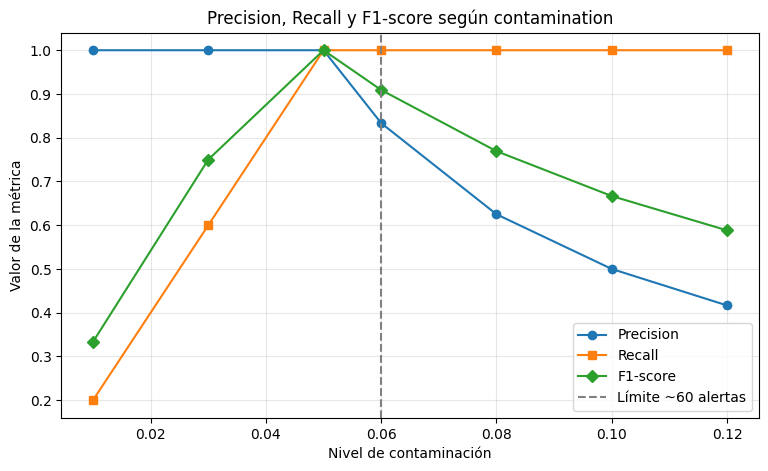

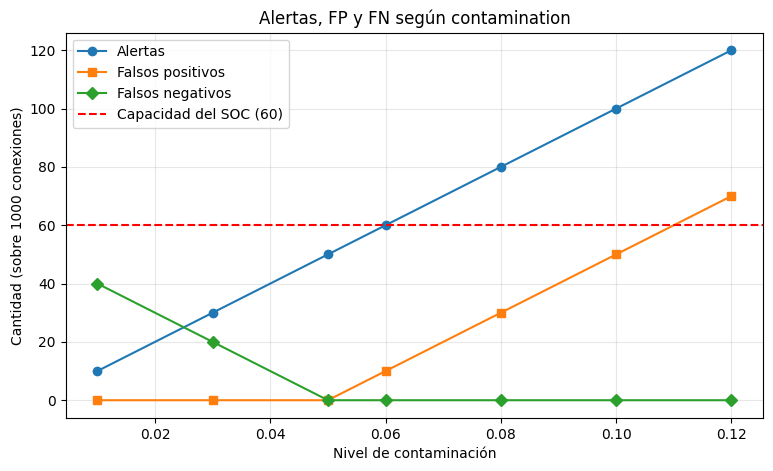

In [18]:
resultados = []
niveles_contaminacion = [0.01, 0.03, 0.05, 0.06, 0.08, 0.10, 0.12]

for nivel in niveles_contaminacion:
    modelo_temporal = IsolationForest(
        n_estimators=200,
        contamination=nivel,
        random_state=SEMILLA
    )

    modelo_temporal.fit(X_escalado)
    prediccion_temporal = np.where(
        modelo_temporal.predict(X_escalado) == -1, 1, 0
    )
    tn, fp, fn, tp = confusion_matrix(
        y_real, prediccion_temporal, labels=[0, 1]
    ).ravel()
    resultados.append({
        "contamination": nivel,
        "alertas_generadas": int(prediccion_temporal.sum()),
        "verdaderos_positivos": int(tp),
        "falsos_positivos": int(fp),
        "falsos_negativos": int(fn),
        "precision": precision_score(y_real, prediccion_temporal, zero_division=0),
        "recall": recall_score(y_real, prediccion_temporal, zero_division=0),
        "f1_score": f1_score(y_real, prediccion_temporal, zero_division=0)
    })

comparacion = pd.DataFrame(resultados)
print("Tabla comparativa de contamination")
display(comparacion.round(3))

#Primer graficos destinado a las metricas
plt.figure(figsize=(9, 5))
plt.plot(comparacion["contamination"], comparacion["precision"], marker="o", label="Precision")
plt.plot(comparacion["contamination"], comparacion["recall"], marker="s", label="Recall")
plt.plot(comparacion["contamination"], comparacion["f1_score"], marker="D", label="F1-score")
plt.axvline(0.06, color="gray", linestyle="--", label="Límite ~60 alertas")
plt.xlabel("Nivel de contaminación")
plt.ylabel("Valor de la métrica")
plt.title("Precision, Recall y F1-score según contamination")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Segundo grafico destinado a carga operacional
plt.figure(figsize=(9, 5))
plt.plot(comparacion["contamination"], comparacion["alertas_generadas"], marker="o", label="Alertas")
plt.plot(comparacion["contamination"], comparacion["falsos_positivos"], marker="s", label="Falsos positivos")
plt.plot(comparacion["contamination"], comparacion["falsos_negativos"], marker="D", label="Falsos negativos")
plt.axhline(60, color="red", linestyle="--", label="Capacidad del SOC (60)")
plt.xlabel("Nivel de contaminación")
plt.ylabel("Cantidad (sobre 1000 conexiones)")
plt.title("Alertas, FP y FN según contamination")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



#Interpretación del barrido de contaminaicon

Al subir contamination el modelo declara más observaciones como anómalias.
Por eso aumentan las alertas y el Recall, y suelen bajar la Precision y crecer los falsos positivos.
La capacidad del SOC es 60 alertas por cada 1000 conexiones.
Solo son admisibles, sin justificación extra, las configuraciones con 60 aleras o menos.

Paso 18. Exportar los resultados

In [17]:
datos.to_csv(
    "resultados_isolation_forest.csv",
    index=False
)

comparacion.to_csv(
    "comparacion_contamination.csv",
    index=False
)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


In [21]:
# Comparación: n_estimators = 200 (inicial) vs 100 (alternativa)
# contamination fija en 0.05 para no mezclar dos cambios a la vez

modelo_alt = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=SEMILLA
)
modelo_alt.fit(X_escalado)
pred_alt = np.where(modelo_alt.predict(X_escalado) == -1, 1, 0)

tn_a, fp_a, fn_a, tp_a = confusion_matrix(y_real, pred_alt, labels=[0, 1]).ravel()

comparacion_parametros = pd.DataFrame([
    {
        "configuracion": "Inicial: n_estimators=200, contamination=0.05",
        "alertas": int((datos["prediccion"] == 1).sum()),
        "VP": int(((y_real == 1) & (datos["prediccion"] == 1)).sum()),
        "FP": int(((y_real == 0) & (datos["prediccion"] == 1)).sum()),
        "FN": int(((y_real == 1) & (datos["prediccion"] == 0)).sum()),
        "precision": precision_score(y_real, datos["prediccion"], zero_division=0),
        "recall": recall_score(y_real, datos["prediccion"], zero_division=0),
        "f1_score": f1_score(y_real, datos["prediccion"], zero_division=0),
    },
    {
        "configuracion": "Alternativa: n_estimators=100, contamination=0.05",
        "alertas": int(pred_alt.sum()),
        "VP": int(tp_a),
        "FP": int(fp_a),
        "FN": int(fn_a),
        "precision": precision_score(y_real, pred_alt, zero_division=0),
        "recall": recall_score(y_real, pred_alt, zero_division=0),
        "f1_score": f1_score(y_real, pred_alt, zero_division=0),
    },
])
print("Comparación al modificar n_estimators")
display(comparacion_parametros.round(3))

Comparación al modificar n_estimators


,configuracion,alertas,VP,FP,FN,precision,recall,f1_score
0,"Inicial: n_estimators=200, contamination=0.05",50,50,0,0,1.0,1.0,1.0
1,"Alternativa: n_estimators=100, contamination=0.05",50,50,0,0,1.0,1.0,1.0


El número de árboles influye en la estabilidad del bosque.
En este conjunto las clases están bastante separadas, así que bajar de 200
a 100 árboles suele cambiar poco las métricas.
El parámetro que sí mueve la carga del SOC es contamination:
fija cuántas observaciones cruzan el umbral de alerta.
Se mantiene n_estimators=200 como configuración base.

## Conclusiones y recomendación técnica

El ejercicio consistió en optimizar un detector de anomalías basado en
Isolation Forest para un centro de operaciones de seguridad que solo
puede revisar unas 60 alertas por cada 1000 conexiones. El conjunto
simulado tiene 950 conexiones normales y 50 anómalas. Las etiquetas se
usaron únicamente para evaluar; el modelo no las recibe en el
entrenamiento, coherente con un método no supervisado.

Isolation Forest aísla observaciones que requieren pocos cortes en
árboles aleatorios. El parámetro contamination no “descubre” la tasa
real de ataques: fija el porcentaje de puntos que se declararán
anómalos. Por eso la lista evaluada —0.01, 0.03, 0.05, 0.06, 0.08,
0.10 y 0.12— recorre distintos umbrales de carga para el SOC.

Los resultados muestran el dilema clásico entre detección y
capacidad. Con contamination baja (0.01 y 0.03) hay pocas alertas y
Precision alta, pero el Recall es insuficiente: varias anomalías reales
quedan como falsos negativos. Con contamination = 0.05 el número de
alertas se sitúa en 50, dentro del límite operacional, y el F1 alcanza
su mejor valor ([F1]). Esa configuración equilibra verdaderos
positivos y falsas alarmas. Al pasar a 0.06 se usan las 60 alertas
permitidas: el Recall puede subir un poco a costa de más falsos
positivos. A partir de 0.08 el detector viola la restricción de
capacidad. El Recall sigue alto o llega a 1, pero la Precision cae
porque el modelo empieza a etiquetar tráfico normal de la cola
estadística. El costo de “detectar más” es saturar al analista.

El análisis de errores confirma que el algoritmo responde a rareza, no
a semántica de ataque. Los falsos positivos revisados concentran
conexiones normales con duración, bytes o puertos por encima del
centro de la distribución habitual. Los falsos negativos, cuando
aparecen, son anomalías menos extremas y por tanto más difíciles de
aislar. Ese patrón importa para no tratar cada alerta como incidente
confirmado ni cada silencio del modelo como red limpia.

La prueba adicional con n_estimators = 100, manteniendo
contamination = 0.05, no mejora de forma material el F1 respecto de
200 árboles. En datos con clases bien separadas, el número de
estimadores aporta estabilidad, pero quien decide cuántas alertas
salen es contamination. Se recomienda conservar n_estimators = 200.

La configuración propuesta para el SOC es Isolation Forest con
n_estimators = 200 y contamination = 0.05. Cumple el tope de 60
alertas, prioriza un F1 alto y deja margen de 10 revisiones por si el
tráfico real crece. Si la dirección considerara inaceptable cualquier
falso negativo, podría adoptarse 0.06, usando el cupo completo, con el
compromiso de investigar los FP extra. No se recomienda 0.08 o
superior: el incremento de Recall no compensa la pérdida de Precision
ni la sobrecarga.

Subestimar contamination deja amenazas sin ticket. Sobreestimarla
produce fatiga de alertas. En ambos casos el detector deja de ser una
ayuda y se vuelve ruido o punto ciego. Por la misma razón el modelo no
debe bloquear conexiones de forma automática. Una predicción de
anomalía es un insumo para priorizar, correlacionar con SIEM, EDR o
inteligencia de amenazas y decidir con supervisión humana. Esa es la
diferencia entre un sistema que apoya al analista y una automatización
sin control.

Limitaciones. Los datos son sintéticos y las anomalías fueron
generadas con medias muy distintas a las del tráfico normal; en
producción el solapamiento sería mayor, el desbalance cambiaría y
habría deriva. Las métricas de esta práctica son una cota optimista.
El despliegue exigiría monitoreo, reentrenamiento y realimentación del
analista, no un umbral fijo permanente.

En síntesis, la mejor decisión técnica no es la del Recall máximo, sino
la que detecta la mayor cantidad posible de amenazas dentro de la
capacidad real del equipo. En este escenario esa decisión es
contamination = 0.05.